# Milestone 3 — Static batching

The per-step floor is paid per **step**, not per token. Batching splits it.

In [8]:
!git clone https://github.com/Jayaprakash-030/tiny-inference-engine.git
%cd tiny-inference-engine
!pip install -q -e .

Cloning into 'tiny-inference-engine'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 41 (delta 13), reused 40 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 77.76 KiB | 710.00 KiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/tiny-inference-engine/tiny-inference-engine
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiny-inference-engine (pyproject.toml) ... done


In [9]:
from engine import load
from engine.batched import (
    batched_generate,
    check_batch_matches_single,
    print_generations,
    staggered_limits,
    sweep,
)
from engine.prompts import BATCH
from engine.results import save

rt = load()
rt.describe()


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

model : Qwen/Qwen3-0.6B
device: cuda
dtype : torch.float16
layers: 28
gpu   : Tesla T4


### Correctness first

In [10]:
assert check_batch_matches_single(rt, BATCH[:4]), "batching diverged — check padding / position_ids"

batch matches single: True


In [11]:
batched_generate(rt, BATCH[:2], max_new_tokens=16)   # warmup
print("warmup done")

warmup done


### Per-seq limits (so waste is visible)

Open prompts almost never hit EOS under greedy decoding, so a shared
`max_new_tokens` makes every sequence run the same length and
`wasted_slot_pct` stays 0. Real serving gives each request its own
`max_tokens`. Staggered limits recreate that finish-time skew.


In [12]:
MAX_NEW = 200
prompts = BATCH[:4]
limits = staggered_limits(len(prompts), MAX_NEW)
print("limits:", limits)

out, step_ms, kept, computed = batched_generate(
    rt, prompts, max_new_tokens=MAX_NEW, max_new_tokens_per_seq=limits,
)
print_generations(rt, prompts, out, MAX_NEW, limits=limits)
print(f"kept={kept} computed={computed} "
      f"wasted_slot_pct={100 * (computed - kept) / computed:.1f}%")


limits: [50, 100, 150, 200]
steps_run=200/200  eos=0/4  limit=3/4  cap=1/4
per-seq limits: [50, 100, 150, 200]
  [0] gen_tokens=  50  stopped=LIMIT limit=50  'The capital of France is'
       ' Paris. The capital of Italy is Rome. The capital of Spain is Madrid. The capital of China is Beijing. The capital of Ja'
  [1] gen_tokens= 100  stopped=LIMIT limit=100  'Explain how a GPU executes a matrix mult'
       ' What is the difference between a GPU and a CPU in terms of processing power and performance? What are the advantages of'
  [2] gen_tokens= 150  stopped=LIMIT limit=150  'In 2026, the most important trend in mac'
       ' the development of deep learning. This is because of the development of the neural network architecture, which allows f'
  [3] gen_tokens= 200  stopped=CAP limit=200  'def fibonacci(n):'
       '\n    if n == 0:\n        return 0\n    elif n == 1:\n        return 1\n    else:\n        return fibonacci(n-1) + fibonacci(n'
kept=500 computed=800 wasted_slot_pct=37.

### Throughput sweep

`sweep(..., stagger=True)` (default) uses staggered per-seq limits so
`wasted_slot_pct` is the argument for milestone 4.


In [13]:
# Go past 32 so throughput can flatten (or hit OOM — sweep stops there).
m3 = sweep(rt, sizes=(1, 2, 4, 8, 16, 32, 64, 128, 256), max_new_tokens=200, stagger=True)
save(m3)


batch  1:    22.82 tok/s total,  22.82 per seq,   0.0% wasted, steps 200/200, limit 0/1, gen 200-200, 1.232 GB
batch  2:    38.55 tok/s total,   25.7 per seq,  25.0% wasted, steps 200/200, limit 1/2, gen 100-200, 1.253 GB
batch  4:    59.68 tok/s total,  23.87 per seq,  37.5% wasted, steps 200/200, limit 3/4, gen 50-200, 1.309 GB
batch  8:   108.32 tok/s total,  24.07 per seq,  43.8% wasted, steps 200/200, limit 7/8, gen 25-200, 1.414 GB
batch 16:   220.54 tok/s total,  25.95 per seq,  46.9% wasted, steps 200/200, limit 15/16, gen 12-200, 1.627 GB
batch 32:   387.85 tok/s total,  23.51 per seq,  48.4% wasted, steps 200/200, limit 31/32, gen 6-200, 2.053 GB
batch 64:   628.07 tok/s total,  19.33 per seq,  49.2% wasted, steps 200/200, limit 63/64, gen 3-200, 2.907 GB
batch 128:   764.72 tok/s total,  11.86 per seq,  49.6% wasted, steps 200/200, limit 127/128, gen 2-200, 4.609 GB
batch 256:   783.22 tok/s total,    6.1 per seq,  49.8% wasted, steps 200/200, limit 255/256, gen 1-200, 8.015

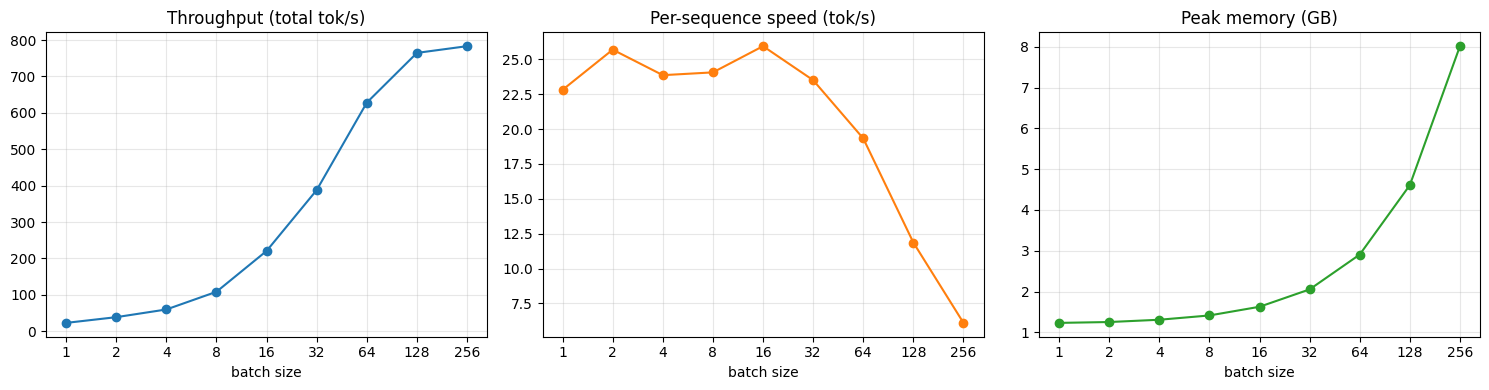

In [14]:
import matplotlib.pyplot as plt

from pathlib import Path

Path("benchmarks/plots").mkdir(parents=True, exist_ok=True)

sizes = [r["batch_size"] for r in m3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title, color in [
    (axes[0], "tokens_per_sec", "Throughput (total tok/s)", "tab:blue"),
    (axes[1], "per_seq_tok_per_sec", "Per-sequence speed (tok/s)", "tab:orange"),
    (axes[2], "peak_mem_gb", "Peak memory (GB)", "tab:green"),
]:
    ax.plot(sizes, [r[key] for r in m3], marker="o", color=color)
    ax.set_title(title)
    ax.set_xlabel("batch size")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sizes)
    ax.set_xticklabels(sizes)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmarks/plots/m3_batching.png", dpi=140)
plt.show()

Throughput climbs then flattens — the knee is where the GPU stops being launch-bound.
Per-sequence speed drifts *down*: throughput up, individual latency down, the central
trade in serving.

`wasted_slot_pct` is the argument for milestone 4.